In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
method_list= ["CCGL", "CCGM"]
budget_list = [1,2,3]
scale_list = [2]
seed_list = [i for i in range(1,11)]
time_limit = 43200

In [4]:
df = dict()
for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            for seed in seed_list:
                timehorizon = 21*scale
                csv_path = f"Rostering/{seed}_{timehorizon}_{method}_{budget}_{time_limit}.csv"
                df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
                # print(f"Method: {method}, Budget: {budget}, Scale: {scale}, Seed: {seed}")
                # print(df_csv.head())
                df[(method, budget, scale, seed)] = df_csv

FileNotFoundError: [Errno 2] No such file or directory: 'Rostering/1_42_CCGL_1_43200.csv'

In [50]:
time_dict = dict()
gap_list = dict()
time_worst_case = dict()
outer_iter = dict()
inner_iter = dict()
for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            for seed in seed_list:
                time_dict[(method, budget, scale, seed)] = float(df[(method, budget, scale, seed)].iloc[3,1])
                gap_list[(method, budget, scale, seed)] = float(df[(method, budget, scale, seed)].iloc[6,1])
                time_worst_case[(method, budget, scale, seed)] = [float(l) for l in df[(method, budget, scale, seed)].iloc[7:,1]]
                outer_iter[(method, budget, scale, seed)] = [float(l) for l in df[(method, budget, scale, seed)].iloc[7:,2]]
                inner_iter[(method, budget, scale, seed)] = [float(l) for l in df[(method, budget, scale, seed)].iloc[7:,3]]

In [51]:
instance_solved = dict()
average_time = dict()
average_gap = dict()
average_nb_worstcase = dict()
average_time_worstcase = dict()
nb_average_inner_iter = dict()
K=300
for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            instance_solved[(method, budget, scale)] = sum([1 for seed in seed_list if time_dict[(method, budget, scale, seed)] < time_limit-1])
            average_time[(method, budget, scale)] = sum([time_dict[(method, budget, scale, seed)] for seed in seed_list if time_dict[(method, budget, scale, seed)] < time_limit-1]) / instance_solved[(method, budget, scale)] if instance_solved[(method, budget, scale)] > 0 else 0
            average_gap[(method, budget, scale)] = sum([gap_list[(method, budget, scale, seed)] for seed in seed_list if time_dict[(method, budget, scale, seed)] >= time_limit-1]) / (10-instance_solved[(method, budget, scale)]) if instance_solved[(method, budget, scale)] < 10 else 0
            average_nb_worstcase[(method, budget, scale)] = sum([len(time_worst_case[(method, budget, scale, seed)]) for seed in seed_list]) / 10


            average_time_worstcase[(method, budget, scale)] = [sum([t for seed in seed_list for (i,t) in enumerate(time_worst_case[(method, budget, scale, seed)]) if inner_iter[(method, budget, scale, seed)][i] == k]) / (1e-10 + sum([1 for seed in seed_list for (i,t) in enumerate(time_worst_case[(method, budget, scale, seed)]) if inner_iter[(method, budget, scale, seed)][i] == k])) for k in range(K)]
            nb_average_inner_iter[(method, budget, scale)] = [sum([1 for seed in seed_list for (i,t) in enumerate(time_worst_case[(method, budget, scale, seed)]) if inner_iter[(method, budget, scale, seed)][i] == k]) for k in range(K)]

In [52]:
# Créer un DataFrame avec tous les résultats
results_data = []

for method in method_list:
    for budget in budget_list:
        for scale in scale_list:
            results_data.append({
                'method': method,
                'budget_scale': (budget, 21*scale),
                'solved': f"{instance_solved[(method, budget, scale)]}/10",
                'average_time': round(average_time[(method, budget, scale)], 2),
                'average_gap': round(average_gap[(method, budget, scale)], 2),
                'average_nb_worst_case': round(average_nb_worstcase[(method, budget, scale)], 2)
            })

# Créer le DataFrame et l'exporter en CSV
results_df = pd.DataFrame(results_data)
results_df.to_csv('results_2.csv', index=False)
print(results_df)


  method budget_scale solved  average_time  average_gap  average_nb_worst_case
0   CCGL      (3, 42)   7/10      15192.05        91.77                  869.8
1   CCGL      (6, 42)   2/10       5863.78        80.86                  770.9
2   CCGL      (9, 42)   1/10       2052.99        81.30                  670.0
3   CCGM      (3, 42)   6/10       9338.21        69.03                  851.3
4   CCGM      (6, 42)   2/10       8171.98        80.86                  681.9
5   CCGM      (9, 42)   1/10       2498.20        81.30                  546.9


In [45]:
average_nb_worstcase

{('CCGL', 3, 1): 0.0,
 ('CCGL', 6, 1): 0.0,
 ('CCGL', 9, 1): 0.0,
 ('CCGM', 3, 1): 0.0,
 ('CCGM', 6, 1): 0.0,
 ('CCGM', 9, 1): 0.0}

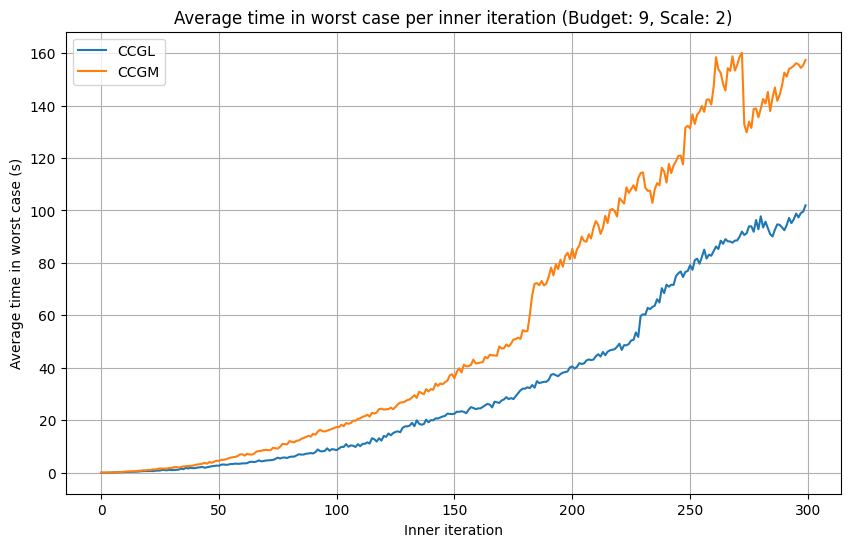

In [61]:
budget = 9
scale = 2
plt.figure(figsize=(10,6))
for method in method_list:
    plt.plot(range(K), average_time_worstcase[(method, budget, scale)], label=method)
plt.xlabel("Inner iteration")
plt.ylabel("Average time in worst case (s)")
plt.title(f"Average time in worst case per inner iteration (Budget: {budget}, Scale: {scale})")
plt.legend()
plt.grid()
plt.savefig(f"time_comparison_rostering_{budget}.pdf")

In [82]:
method_list= ["CCGL", "CCGM"]
budget_list = [1,2,3]
size_list = [1,2,3]
time_limit = 64800

In [84]:
df = dict()
for method in method_list:
    for budget in budget_list:
        for size in size_list:
            if size == 1:
                name = "IEEE3"
            elif size == 2:
                name = "IEEE12"
            elif size == 3:
                name = "IEEE54"
            csv_path = f"UC/{name}_{method}_{budget}_{time_limit}.csv"
            df_csv = pd.read_csv(csv_path, sep=",", encoding="utf-8")
            # print(f"Method: {method}, Budget: {budget}, Scale: {scale}, Seed: {seed}")
            # print(df_csv.head())
            df[(method, budget, size)] = df_csv

In [85]:
time_dict = dict()
gap_list = dict()
time_worst_case = dict()
outer_iter = dict()
inner_iter = dict()
for method in method_list:
    for budget in budget_list:
        for size in size_list:
                time_dict[(method, budget, size)] = float(df[(method, budget, size)].iloc[3,1])
                gap_list[(method, budget, size)] = float(df[(method, budget, size)].iloc[6,1])
                time_worst_case[(method, budget, size)] = [float(l) for l in df[(method, budget, size)].iloc[7:,1]]
                outer_iter[(method, budget, size)] = [float(l) for l in df[(method, budget, size)].iloc[7:,2]]
                inner_iter[(method, budget, size)] = [float(l) for l in df[(method, budget, size)].iloc[7:,3]]

In [97]:
instance_solved = dict()
average_time = dict()
average_gap = dict()
average_nb_worstcase = dict()
average_time_worstcase = dict()
nb_average_inner_iter = dict()
K=50
for method in method_list:
    for budget in budget_list:
        for size in size_list:
            instance_solved[(method, budget, size)] = 1 if time_dict[(method, budget, size)] < time_limit - 1 else 0
            average_time[(method, budget, size)] = time_dict[(method, budget, size)]
            average_gap[(method, budget, size)] = gap_list[(method, budget, size)]
            average_nb_worstcase[(method, budget, size)] = sum([len(time_worst_case[(method, budget, size)])])


            average_time_worstcase[(method, budget, size)] = [sum([t for (i,t) in enumerate(time_worst_case[(method, budget, size)]) if inner_iter[(method, budget, size)][i] == k]) / (1e-10 + sum([1 for (i,t) in enumerate(time_worst_case[(method, budget, size)]) if inner_iter[(method, budget, size)][i] == k])) for k in range(K)]
            nb_average_inner_iter[(method, budget, size)] = [sum([1 for (i,t) in enumerate(time_worst_case[(method, budget, size)]) if inner_iter[(method, budget, size)][i] == k]) for k in range(K)]

In [87]:
# Créer un DataFrame avec tous les résultats
results_data = []

for method in method_list:
    for budget in budget_list:
        for size in size_list:
            results_data.append({
                'method': method,
                'size' : size,
                'budget_scale': budget,
                'solved': f"{instance_solved[(method, budget, size)]}/1",
                'average_time': round(average_time[(method, budget, size)], 2),
                'average_gap': round(average_gap[(method, budget, size)], 2),
                'average_nb_worst_case': round(average_nb_worstcase[(method, budget, size)], 2)
            })

# Créer le DataFrame et l'exporter en CSV
results_df = pd.DataFrame(results_data)
results_df.to_csv('results_UC.csv', index=False)
print(results_df)

   method  size  budget_scale solved  average_time  average_gap  \
0    CCGL     1             1    1/1         13.83         0.01   
1    CCGL     2             1    0/1     117450.53         1.37   
2    CCGL     3             1    1/1      36903.25         0.12   
3    CCGL     1             2    1/1       5068.80         0.18   
4    CCGL     2             2    0/1      65042.42        94.84   
5    CCGL     3             2    0/1      65882.60        95.29   
6    CCGL     1             3    0/1      64809.00         1.61   
7    CCGL     2             3    0/1      64838.29        94.83   
8    CCGL     3             3    0/1      65733.18        95.28   
9    CCGM     1             1    1/1         13.24         0.02   
10   CCGM     2             1    0/1     118306.72         1.37   
11   CCGM     3             1    1/1      55128.40         0.14   
12   CCGM     1             2    1/1       7346.58         0.10   
13   CCGM     2             2    0/1      64925.61        94.8

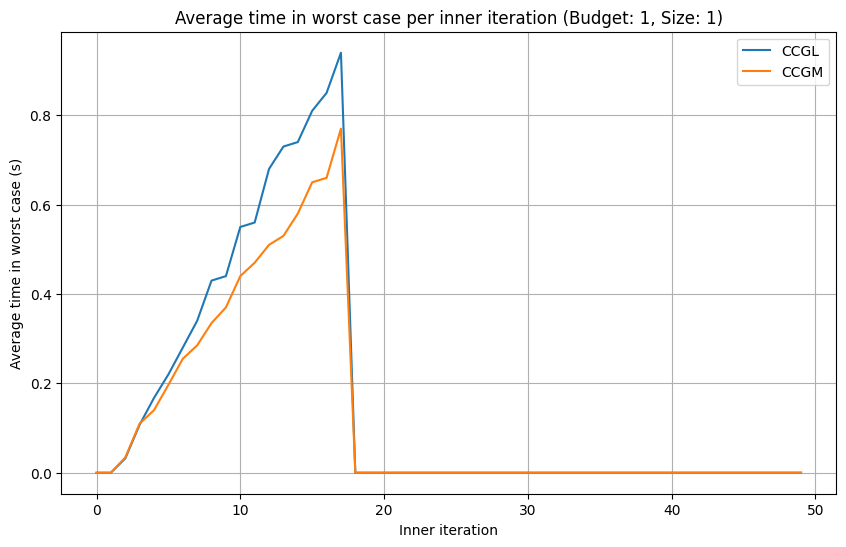

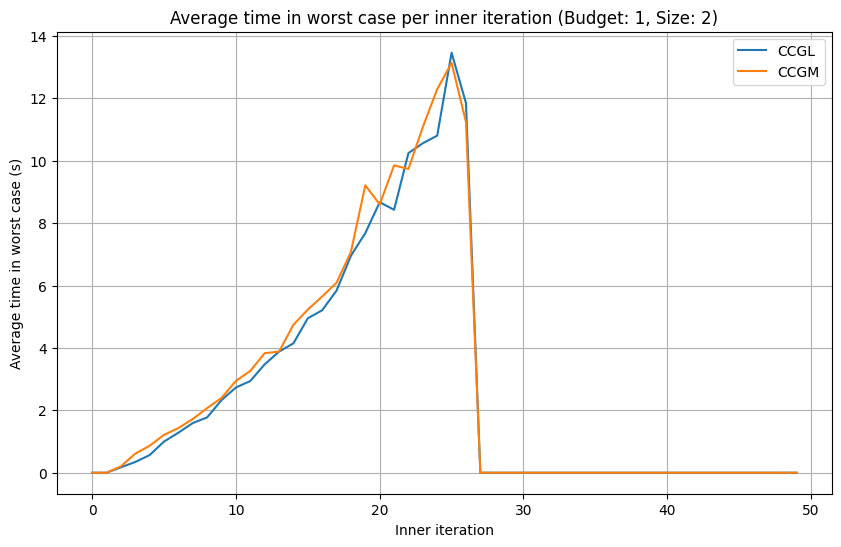

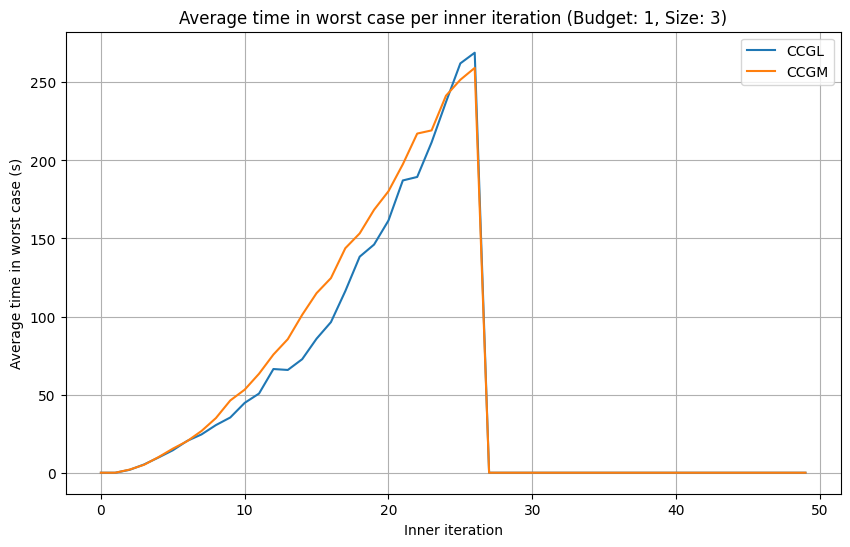

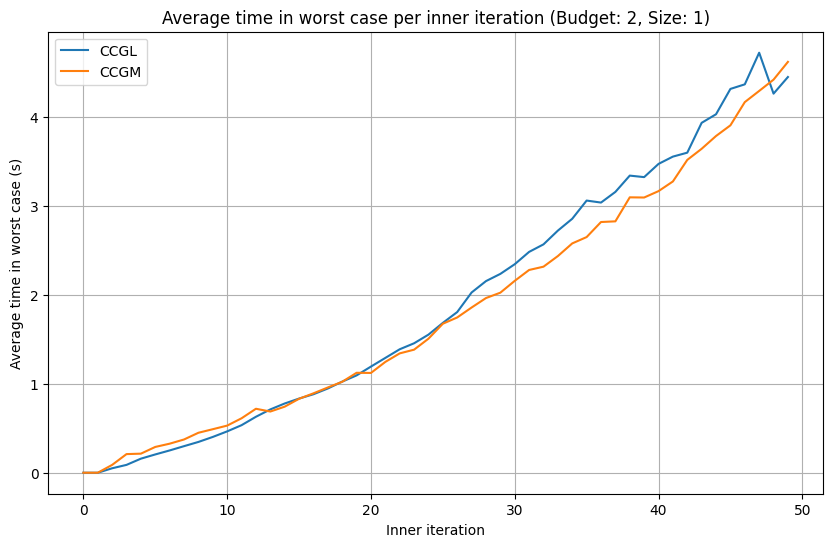

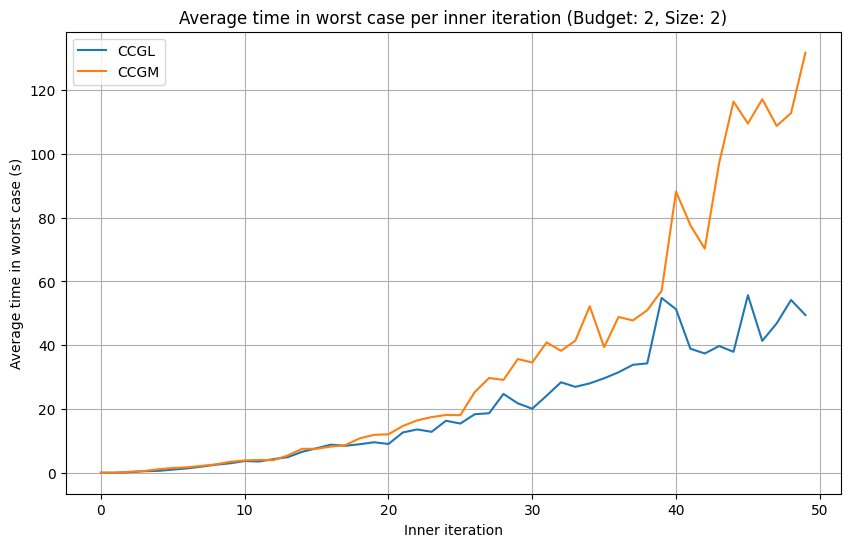

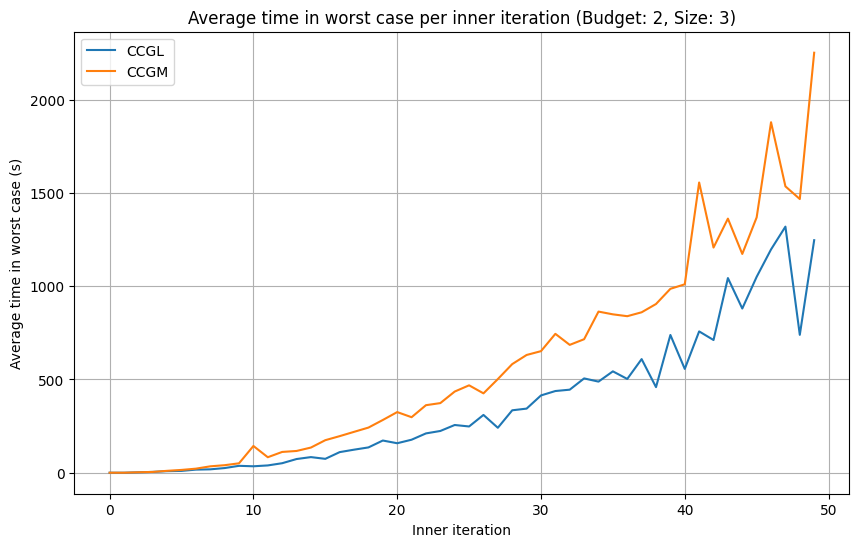

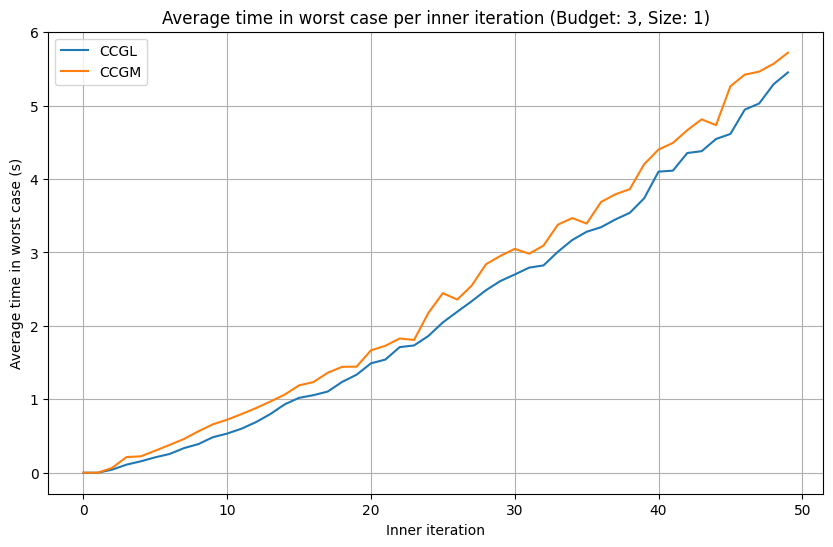

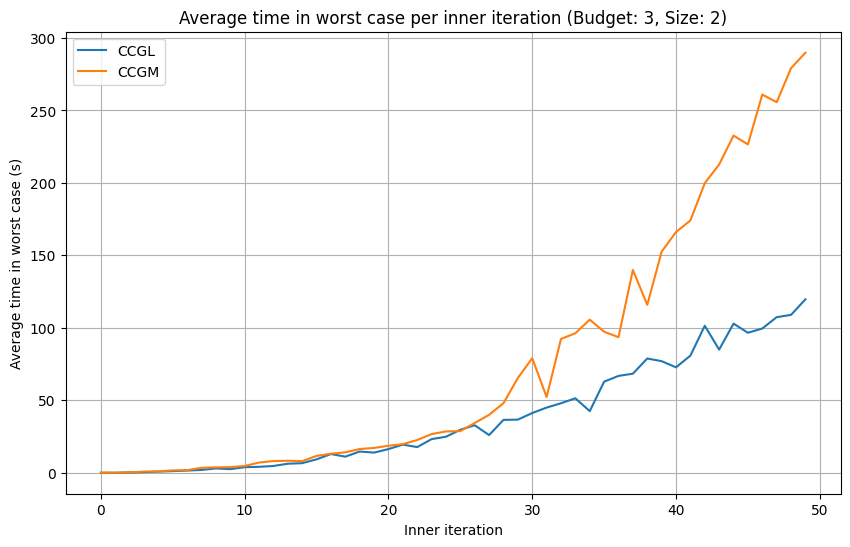

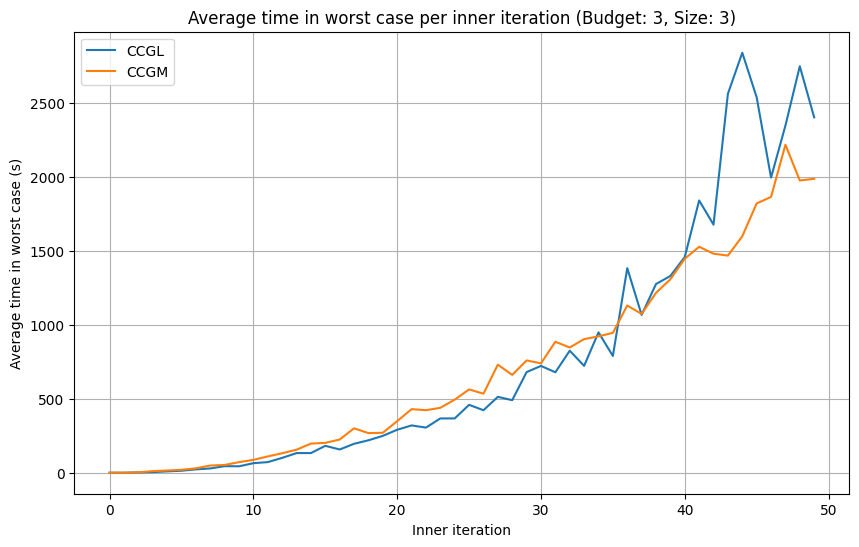

In [99]:
for budget in budget_list:
    for size in size_list:
        plt.figure(figsize=(10,6))
        for method in method_list:
            plt.plot(range(K), average_time_worstcase[(method, budget, size)], label=method)
        plt.xlabel("Inner iteration")
        plt.ylabel("Average time in worst case (s)")
        plt.title(f"Average time in worst case per inner iteration (Budget: {budget}, Size: {size})")
        plt.legend()
        plt.grid()
        plt.savefig(f"time_comparison_UC_{size}_{budget}.pdf")